In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

DATA_DIR = Path("../data-raw")
classes = ["moon", "jupiter", "saturn"]

for cls in classes:
    files = list((DATA_DIR / cls).glob("*"))
    print(f"{cls}: {len(files)} images")

moon: 23 images
jupiter: 32 images
saturn: 25 images


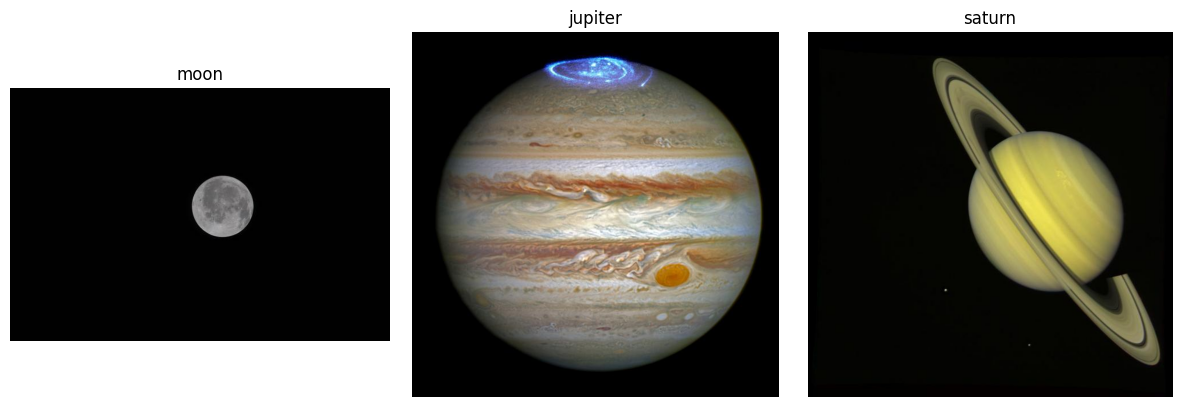

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, cls in enumerate(classes):
    image_path = list((DATA_DIR / cls).glob("*"))[0]
    img = Image.open(image_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [10]:
RAW_DIR = Path("../data-raw")
PROCESSED_DIR = Path("../data-processed")

classes = ["moon", "jupiter", "saturn"]
TARGET_SIZE = (224, 224)

for cls in classes:
    input_dir = RAW_DIR / cls
    output_dir = PROCESSED_DIR / cls
    output_dir.mkdir(parents=True, exist_ok=True)

    for image_path in input_dir.glob("*"):
        try:
            img = Image.open(image_path).convert("RGB")
            img = img.resize(TARGET_SIZE)

            output_path = output_dir / image_path.name
            img.save(output_path)

        except Exception as e:
            print(f"Error processing {image_path.name}: {e}")

print("Preprocessing complete.")

Preprocessing complete.


In [5]:
for cls in classes:
    files = list((PROCESSED_DIR / cls).glob("*"))
    print(f"{cls}: {len(files)} processed images")

moon: 23 processed images
jupiter: 32 processed images
saturn: 25 processed images


In [6]:
sample_path = list((PROCESSED_DIR / "moon").glob("*"))[0]
img = Image.open(sample_path)

print("Image size:", img.size)

Image size: (224, 224)


In [7]:
sample_path = list((PROCESSED_DIR / "saturn").glob("*"))[0]
img = Image.open(sample_path)

print("Image size:", img.size)

Image size: (224, 224)


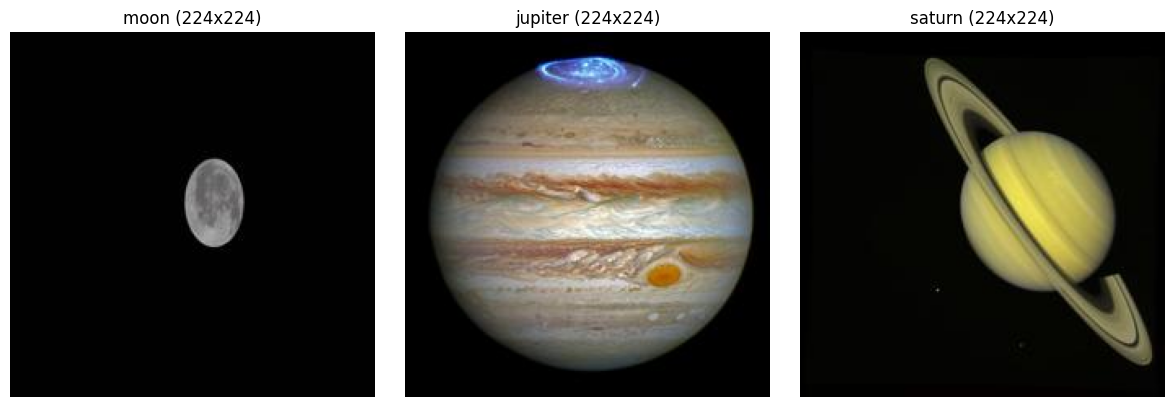

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, cls in enumerate(classes):
    image_path = list((PROCESSED_DIR / cls).glob("*"))[0]
    img = Image.open(image_path)

    axes[i].imshow(img)
    axes[i].set_title(f"{cls} (224x224)")
    axes[i].axis("off")

plt.tight_layout()
plt.show()